In [1]:
from sympy import*
init_printing()
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
x,y = symbols("x y")
A15 = 0.15
A3 = 0.32
A45 = 0.67
V15 = 1.5
V3 = 3
V45 = 4.5
Vss, iss = symbols("V_ss I_ss")
R = iss/Vss # there for
R15 = V15 / A15 
R3 = V3 / A3 
R45 = V45 / A45
R15, R3 , R45



In [3]:
R = 0.1
0.15 * 0.632
tau = 0.0225
L = tau * R


In [4]:
m_regbot = 927 # [g]



## Motor-log plots

The MATLAB analysis uses this same reproducible 6 V capture.

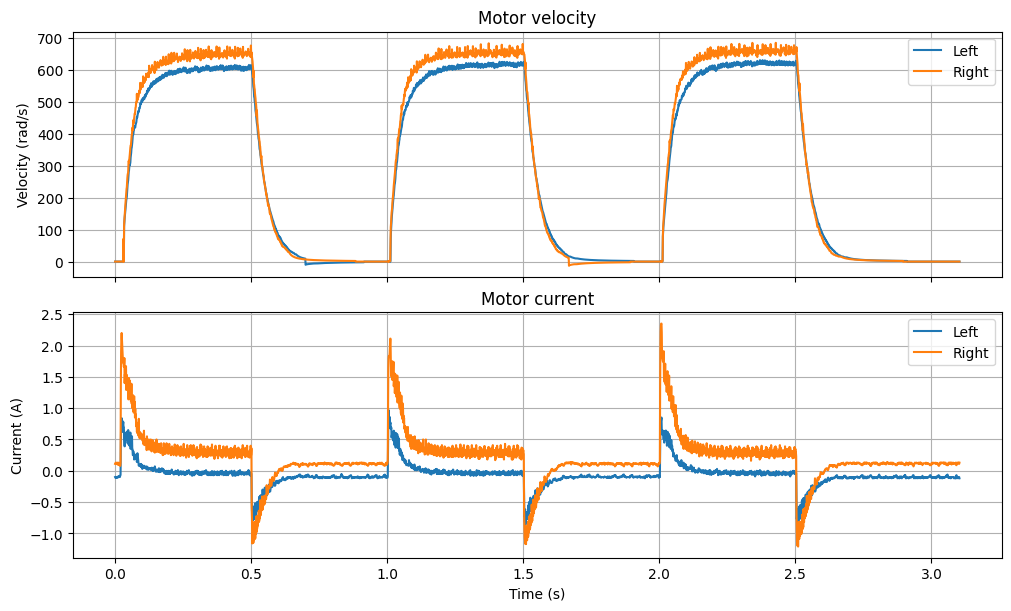

In [5]:
repo_root = next(path for path in (Path.cwd(), *Path.cwd().parents)
                 if (path / "src" / "logs").is_dir())
log_path = repo_root / "src" / "logs" / "device-monitor-260909-113357.log"
data = np.loadtxt(log_path, comments="%")

time_s = data[:, 0]
voltage_v = data[:, 3:5]
velocity_rad_s = data[:, 7:9]
current_a = data[:, 14:16]

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6), layout="constrained")
axes[0].plot(time_s, velocity_rad_s[:, 0], label="Left")
axes[0].plot(time_s, velocity_rad_s[:, 1], label="Right")
axes[0].set(title="Motor velocity", ylabel="Velocity (rad/s)")
axes[0].grid()
axes[0].legend()

axes[1].plot(time_s, current_a[:, 0], label="Left")
axes[1].plot(time_s, current_a[:, 1], label="Right")
axes[1].set(title="Motor current", xlabel="Time (s)", ylabel="Current (A)")
axes[1].grid()
axes[1].legend()
plt.show()